# Fine-tuning across modalities

Text, image, audio, and video use different data and fail in different
ways. The working loop is to

1. define the task
2. collect pairs
3. measure a baseline on held-out data
4. adapt a compatible base model
5. run the same evaluation again

This file is both the workshop closer and a standalone reference. The
presenter path is the outcome table, the four modality sections, and the
comparison near the end. The reference sections contain chess notation,
provider calls, and trainer configurations.

The default path is offline. It does not call a provider or download a
model. Worked media outputs are labelled as stand-ins until measured
adapter runs replace them.

In [41]:
from __future__ import annotations

import importlib.util
import io
import json
import logging
import os
import random
import sys
import tempfile
import time
from collections.abc import Callable, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import chess
import chess.pgn
import chess.svg
import fal_client
import httpx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG, Audio, Markdown, Video, display
from IPython.display import Image as NotebookImage
from PIL import Image as PILImage
from PIL import ImageDraw
from scipy.io import wavfile

In [42]:
pd.set_option("display.max_colwidth", 100)
plt.rcParams.update(
    {
        "figure.figsize": (8, 3.4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)

In [43]:
def show_markdown(text: str) -> None:
    display(Markdown(text))


def show_table(rows: Sequence[dict[str, Any]], *, precision: int = 3) -> pd.DataFrame:
    frame = pd.DataFrame(rows)
    display(frame.style.hide(axis="index").format(precision=precision, na_rep=""))
    # return frame


def indented(text: str) -> str:
    return "\n".join(f"    {line}" for line in text.splitlines())

In [44]:
ROOT_CANDIDATES = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (path for path in ROOT_CANDIDATES if (path / "CLAUDE.md").is_file()),
    Path.cwd(),
)
EXPECTED_PYTHON = REPO_ROOT / ".venv" / "bin" / "python"
LOGGER = logging.getLogger("ftshop.notebook")
GEMMA_LOCAL_MODEL_ID = "google/gemma-4-E2B-it-qat-q4_0-gguf"
GEMMA_TRAINING_MODEL_ID = "google/gemma-4-E2B-it-qat-q4_0-unquantized"
GEMMA_API_MODEL = os.environ.get("GEMMA_API_MODEL", "gemma-4-2b-local")
VIDEO_PROMPT_MODEL = os.environ.get("VIDEO_PROMPT_MODEL", "gpt-5.6-luna")

In [45]:
REQUIRED_PACKAGES = (
    "chess",
    "fal_client",
    "httpx",
    "jax",
    "matplotlib",
    "numpy",
    "pandas",
    "PIL",
    "scipy",
)
OPTIONAL_CAPABILITIES = {
    "hosted Chat Completions": bool(
        os.environ.get("OPENAI_API_KEY") or os.environ.get("OPENROUTER_API_KEY")
    ),
    "fal media generation": bool(os.environ.get("FAL_KEY")),
}

environment_rows = [
    {
        "item": "Python",
        "ready": Path(sys.executable).resolve() == EXPECTED_PYTHON.resolve(),
        "detail": sys.executable,
    },
    *[
        {
            "item": package,
            "ready": importlib.util.find_spec(package) is not None,
            "detail": "required",
        }
        for package in REQUIRED_PACKAGES
    ],
    *[
        {"item": name, "ready": ready, "detail": "optional"}
        for name, ready in OPTIONAL_CAPABILITIES.items()
    ],
]
show_table(environment_rows)

item,ready,detail
Python,True,/home/rpg/d2/projects/saute/euroscipy26/ftshop/.venv/bin/python
chess,True,required
fal_client,True,required
httpx,True,required
jax,True,required
matplotlib,True,required
numpy,True,required
pandas,True,required
PIL,True,required
scipy,True,required


If Python is not marked ready, select Python (ftshop .venv) in Zed's
kernel picker. No key value is printed or inspected beyond whether it
exists.

## Outcomes first

This table is the notebook in one screen. The rest of the file explains
how each row is built and where its evaluation can lie.

In [46]:
OUTCOME_OVERVIEW = [
    {
        "modality": "text",
        "pair": "position and reference move",
        "adaptation": "LoRA on an instruction model",
        "held-out check": "JSON, legality, reference move, engine score",
        "main failure": "valid syntax with weak chess",
    },
    {
        "modality": "image",
        "pair": "piece image and caption",
        "adaptation": "LoRA on an image model",
        "held-out check": "identity, style consistency, prompt adherence",
        "main failure": "style learned, piece identity lost",
    },
    {
        "modality": "audio",
        "pair": "event text and audio clip",
        "adaptation": "adapter on an audio generator",
        "held-out check": "duration, clipping, audio-text similarity, listeners",
        "main failure": "recognisable sound with the wrong event",
    },
    {
        "modality": "video",
        "pair": "scenario text and video clip",
        "adaptation": "LoRA on a video model",
        "held-out check": "action, identity, temporal consistency, preference",
        "main failure": "good frames that do not form a coherent clip",
    },
]
show_table(OUTCOME_OVERVIEW)

modality,pair,adaptation,held-out check,main failure
text,position and reference move,LoRA on an instruction model,"JSON, legality, reference move, engine score",valid syntax with weak chess
image,piece image and caption,LoRA on an image model,"identity, style consistency, prompt adherence","style learned, piece identity lost"
audio,event text and audio clip,adapter on an audio generator,"duration, clipping, audio-text similarity, listeners",recognisable sound with the wrong event
video,scenario text and video clip,LoRA on a video model,"action, identity, temporal consistency, preference",good frames that do not form a coherent clip


## 1. Why fine-tune, and why chess

Fine-tuning is useful when a prompt is not enough, for example, when the behaviour must be
repeatable, when the output contract matters (e.g. no ceremony "here is what you asked for" 
before the required move), or when a smaller local model must do
the task. In addition, the prompt is a poor place to store facts that change often and 
it is also a poor substitute for an evaluation set.

I played chess when I was younger and returned to it through Duolingo's chess
pathway in April this year. Two matches a day became thirty, and then fifty on the
hardcore days. After more than a thousand matches, my Elo passed 1000 and now,
being the addict that I am, I thought it would be fun to be able to play against a
model that not only would be a good sparring partner but also a really good strategist
that could help me connect the history of a finished game to a real world scenario. Also,
it should run on device without any need for an internet connection. More on this in a bit.

Chess is useful here because the environment can validate a move and replay
a game. That gives us a deterministic constraint and a simulator and although it does
not tell us which legal move is good or bad, it leaves that to the wits of the 
model or, of course, us. Demonstration games, engine analysis, outcomes, or human preferences must provide that signal.

There are quite a few examples on building a chess engine so my preference
is to build an instructor with a particular teaching preference in that, it
should teach me to win while capturing as few opposing pieces as possible.

> To win one hundred victories in one hundred battles is not the acme of skill. To subdue the enemy without fighting is the acme of skill ~ Sun Tzu

### Chess in five minutes

Chess is played on an eight by eight board and white always moves first. The goal
is to checkmate your opponent and this happens when you attack the opposing king
so no legal response remains. Each piece has its own movement rule and a legal
move may still be strategically poor, which is why legality alone cannot be the
sole eval for us to use.

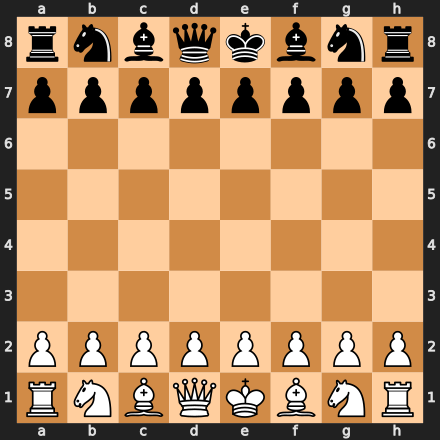

In [47]:
starting_board = chess.Board()
chess.svg.board(board=starting_board, size=440, coordinates=True)

Four representations are enough for this notebook:

- PGN records the game and its move history.
- FEN records one position and its rule state.
- UCI move notation gives an unambiguous source and destination, such as
  e2e4.
- Numeric planes give a custom model structured state rather than text.

Store PGN for the story, FEN for the state, and UCI for the target.

In [48]:
show_table(
    [
        {
            "representation": "PGN",
            "describes": "game history",
            "example": "1. e4 e5 2. Nf3 Nc6",
            "use": "archive and sequence training",
        },
        {
            "representation": "FEN",
            "describes": "one position",
            "example": chess.STARTING_FEN,
            "use": "position input",
        },
        {
            "representation": "UCI move",
            "describes": "one action",
            "example": "e2e4",
            "use": "model target and validation",
        },
        {
            "representation": "planes",
            "describes": "structured state",
            "example": "18 x 8 x 8",
            "use": "custom policy model",
        },
    ]
)

representation,describes,example,use
PGN,game history,1. e4 e5 2. Nf3 Nc6,archive and sequence training
FEN,one position,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1,position input
UCI move,one action,e2e4,model target and validation
planes,structured state,18 x 8 x 8,custom policy model


## 2. Text: one complete adaptation loop

We create the game once. Every later view derives from the same records.

### One canonical game

    [Event "EuroSciPy 2026"]
    [Site "?"]
    [Date "????.??.??"]
    [Round "?"]
    [White "Workshop player"]
    [Black "Workshop opponent"]
    [Result "*"]
    
    1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O *

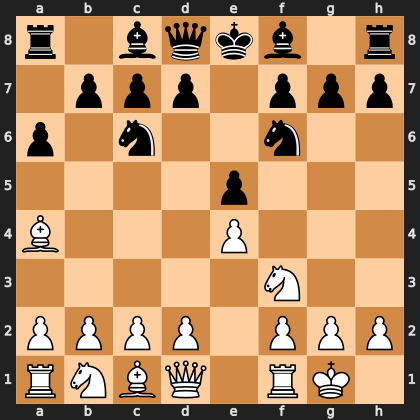

In [49]:
@dataclass(frozen=True)
class MoveRecord:
    game_id: str
    ply: int
    pgn_prefix: str
    san: str
    uci: str
    fen_before: str
    fen_after: str
    legal_moves_before: tuple[str, ...]
    is_check: bool
    is_checkmate: bool
    done: bool


@dataclass(frozen=True)
class ReplayedGame:
    game_id: str
    pgn: str
    records: tuple[MoveRecord, ...]
    final_fen: str
    result: str


def format_pgn_prefix(sans: Sequence[str]) -> str:
    parts: list[str] = []
    for index, san in enumerate(sans):
        parts.append(f"{index // 2 + 1}. {san}" if index % 2 == 0 else san)
    return " ".join(parts)


def replay_game(game_id: str, sans: Sequence[str]) -> ReplayedGame:
    board = chess.Board()
    game = chess.pgn.Game()
    game.headers["Event"] = "EuroSciPy 2026"
    game.headers["White"] = "Workshop player"
    game.headers["Black"] = "Workshop opponent"
    node = game
    records: list[MoveRecord] = []
    prior_sans: list[str] = []

    for ply, supplied_san in enumerate(sans, start=1):
        fen_before = board.fen()
        legal_moves = tuple(move.uci() for move in board.legal_moves)
        move = board.parse_san(supplied_san)
        normalized_san = board.san(move)
        board.push(move)
        node = node.add_variation(move)
        records.append(
            MoveRecord(
                game_id=game_id,
                ply=ply,
                pgn_prefix=format_pgn_prefix(prior_sans),
                san=normalized_san,
                uci=move.uci(),
                fen_before=fen_before,
                fen_after=board.fen(),
                legal_moves_before=legal_moves,
                is_check=board.is_check(),
                is_checkmate=board.is_checkmate(),
                done=board.is_game_over(claim_draw=True),
            )
        )
        prior_sans.append(normalized_san)

    result = (
        board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
    )
    game.headers["Result"] = result
    exporter = chess.pgn.StringExporter(headers=True, variations=False, comments=False)
    return ReplayedGame(
        game_id=game_id,
        pgn=game.accept(exporter),
        records=tuple(records),
        final_fen=board.fen(),
        result=result,
    )


RUY_LOPEZ = replay_game(
    "ruy-lopez",
    ("e4", "e5", "Nf3", "Nc6", "Bb5", "a6", "Ba4", "Nf6", "O-O"),
)

show_markdown("### One canonical game\n\n" + indented(RUY_LOPEZ.pgn))
# display(SVG(
chess.svg.board(board=chess.Board(RUY_LOPEZ.final_fen), size=420)
# ))

### Canonical rows, trainer-specific views

The durable record is position plus action and provenance. Trainer formats
are derived views. This prevents an Axolotl field name from becoming the
workshop's data model.

In [50]:
GAME_LIBRARY = {
    "ruy-lopez": ("e4", "e5", "Nf3", "Nc6", "Bb5", "a6", "Ba4", "Nf6", "O-O"),
    "queens-gambit": ("d4", "d5", "c4", "e6", "Nc3", "Nf6", "Bg5", "Be7"),
    "italian": ("e4", "e5", "Nf3", "Nc6", "Bc4", "Bc5", "c3", "Nf6", "d4"),
    "fools-mate": ("f3", "e5", "g4", "Qh4#"),
}
REPLAYED_GAMES = {
    game_id: replay_game(game_id, sans) for game_id, sans in GAME_LIBRARY.items()
}

TRAIN_GAME_IDS = ("ruy-lopez", "queens-gambit", "italian")
EVAL_GAME_IDS = ("fools-mate",)
TRAIN_RECORDS = tuple(
    record for game_id in TRAIN_GAME_IDS for record in REPLAYED_GAMES[game_id].records
)
EVAL_RECORDS = tuple(
    record for game_id in EVAL_GAME_IDS for record in REPLAYED_GAMES[game_id].records
)


def position_prompt(record: MoveRecord) -> str:
    legal_moves = ", ".join(record.legal_moves_before)
    return (
        "Choose one move for the supplied chess position.\n"
        f"FEN: {record.fen_before}\n"
        f"Legal moves in UCI notation: {legal_moves}\n"
        'Return one JSON object with this shape: {"move": "<uci>"}'
    )


def canonical_row(record: MoveRecord) -> dict[str, Any]:
    return {
        "game_id": record.game_id,
        "ply": record.ply,
        "fen": record.fen_before,
        "legal_moves": list(record.legal_moves_before),
        "target_uci": record.uci,
    }


def prompt_completion_row(record: MoveRecord) -> dict[str, str]:
    return {
        "prompt": position_prompt(record),
        "completion": json.dumps({"move": record.uci}),
    }


CANONICAL_TRAIN_ROWS = [canonical_row(record) for record in TRAIN_RECORDS]
TRAINER_ROWS = [prompt_completion_row(record) for record in TRAIN_RECORDS]
TRAINING_PATH = Path(tempfile.gettempdir()) / "ftshop-chess-sft.jsonl"
TRAINING_PATH.write_text(
    "\n".join(json.dumps(row) for row in TRAINER_ROWS) + "\n",
    encoding="utf-8",
)

show_table(
    [
        {
            "split": "train",
            "games": len(TRAIN_GAME_IDS),
            "positions": len(TRAIN_RECORDS),
        },
        {
            "split": "evaluation",
            "games": len(EVAL_GAME_IDS),
            "positions": len(EVAL_RECORDS),
        },
    ]
)
show_markdown(
    "First canonical row:\n\n"
    + indented(json.dumps(CANONICAL_TRAIN_ROWS[0], indent=2))
    + f"\n\nTrainer JSONL: {TRAINING_PATH}"
)

split,games,positions
train,3,26
evaluation,1,4


First canonical row:

    {
      "game_id": "ruy-lopez",
      "ply": 1,
      "fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
      "legal_moves": [
        "g1h3",
        "g1f3",
        "b1c3",
        "b1a3",
        "h2h3",
        "g2g3",
        "f2f3",
        "e2e3",
        "d2d3",
        "c2c3",
        "b2b3",
        "a2a3",
        "h2h4",
        "g2g4",
        "f2f4",
        "e2e4",
        "d2d4",
        "c2c4",
        "b2b4",
        "a2a4"
      ],
      "target_uci": "e2e4"
    }

Trainer JSONL: /tmp/ftshop-chess-sft.jsonl

The split is by game, not by move. Splitting plies from one game across
training and evaluation would put near-duplicate positions on both sides.
These few rows exercise the pipeline. They are not enough to claim a useful
chess model.

### A real evaluation harness

The predictions below are a deterministic fixture. They are not presented
as measurements from a fine-tuned model. Their purpose is to prove that the
evaluation distinguishes invalid JSON, illegal moves, legal alternatives,
the reference move, and mate in one.

In [51]:
@dataclass(frozen=True)
class EvaluationCase:
    case_id: str
    fen: str
    target_uci: str


EVALUATION_CASES = tuple(
    EvaluationCase(
        case_id=f"{record.game_id}-ply-{record.ply}",
        fen=record.fen_before,
        target_uci=record.uci,
    )
    for record in EVAL_RECORDS
)

BASELINE_FIXTURE = (
    '{"move": "e2e5"}',
    "e7e5",
    '{"move": "g2g3"}',
    '{"move": "d8h4"}',
)
ADAPTED_FIXTURE = tuple(
    json.dumps({"move": case.target_uci}) for case in EVALUATION_CASES
)


def parse_json_object(text: str) -> dict[str, Any] | None:
    candidate = text.strip()
    fence = chr(96) * 3
    if candidate.startswith(fence) and candidate.endswith(fence):
        candidate = candidate[3:-3].strip()
        if candidate.startswith("json"):
            candidate = candidate[4:].strip()
    try:
        parsed = json.loads(candidate)
    except json.JSONDecodeError:
        return None
    return parsed if isinstance(parsed, dict) else None


def parse_move_reply(text: str) -> str | None:
    parsed = parse_json_object(text)
    if parsed is None:
        return None
    move = parsed.get("move")
    return move.strip().lower() if isinstance(move, str) and move.strip() else None


def evaluate_predictions(
    cases: Sequence[EvaluationCase],
    predictions: Sequence[str],
) -> tuple[dict[str, float], list[dict[str, Any]]]:
    if len(cases) != len(predictions):
        raise ValueError("Each evaluation case needs exactly one prediction")

    details: list[dict[str, Any]] = []
    mate_case_count = 0
    mate_success_count = 0

    for case, raw_prediction in zip(cases, predictions, strict=True):
        parsed_object = parse_json_object(raw_prediction)
        proposed_uci = parse_move_reply(raw_prediction)
        board = chess.Board(case.fen)
        target_move = chess.Move.from_uci(case.target_uci)
        target_board = board.copy(stack=False)
        target_board.push(target_move)
        target_is_mate = target_board.is_checkmate()
        mate_case_count += int(target_is_mate)

        proposed_move: chess.Move | None = None
        try:
            proposed_move = chess.Move.from_uci(proposed_uci) if proposed_uci else None
        except ValueError:
            proposed_move = None
        legal = (
            proposed_move in board.legal_moves if proposed_move is not None else False
        )

        proposed_is_mate = False
        if legal and proposed_move is not None:
            proposed_board = board.copy(stack=False)
            proposed_board.push(proposed_move)
            proposed_is_mate = proposed_board.is_checkmate()
        mate_success_count += int(target_is_mate and proposed_is_mate)

        details.append(
            {
                "case": case.case_id,
                "raw": raw_prediction,
                "json_object": parsed_object is not None,
                "parsed_move": proposed_uci,
                "legal": legal,
                "reference_move": proposed_uci == case.target_uci,
                "mate_when_available": proposed_is_mate if target_is_mate else None,
            }
        )

    total = len(details)
    metrics = {
        "JSON object rate": sum(row["json_object"] for row in details) / total,
        "parseable move rate": sum(row["parsed_move"] is not None for row in details)
        / total,
        "legal move rate": sum(row["legal"] for row in details) / total,
        "reference move agreement": sum(row["reference_move"] for row in details)
        / total,
        "mate-in-one success": (
            mate_success_count / mate_case_count if mate_case_count else float("nan")
        ),
    }
    return metrics, details


BASELINE_METRICS, BASELINE_DETAILS = evaluate_predictions(
    EVALUATION_CASES,
    BASELINE_FIXTURE,
)
ADAPTED_METRICS, ADAPTED_DETAILS = evaluate_predictions(
    EVALUATION_CASES,
    ADAPTED_FIXTURE,
)

metric_rows = [
    {
        "metric": metric,
        "baseline fixture": BASELINE_METRICS[metric],
        "adapted fixture": ADAPTED_METRICS[metric],
    }
    for metric in BASELINE_METRICS
]
show_table(metric_rows)
show_table(BASELINE_DETAILS)

metric,baseline fixture,adapted fixture
JSON object rate,0.750,1.000
parseable move rate,0.750,1.000
legal move rate,0.500,1.000
reference move agreement,0.250,1.000
mate-in-one success,1.000,1.000


case,raw,json_object,parsed_move,legal,reference_move,mate_when_available
fools-mate-ply-1,"{""move"": ""e2e5""}",True,e2e5,False,False,
fools-mate-ply-2,e7e5,False,,False,False,
fools-mate-ply-3,"{""move"": ""g2g3""}",True,g2g3,True,False,
fools-mate-ply-4,"{""move"": ""d8h4""}",True,d8h4,True,True,True


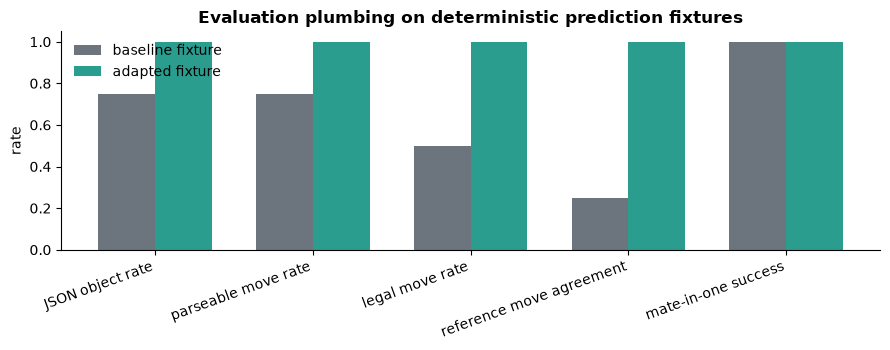

In [52]:
metric_names = list(BASELINE_METRICS)
x_positions = np.arange(len(metric_names))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(
    x_positions - width / 2,
    [BASELINE_METRICS[name] for name in metric_names],
    width,
    label="baseline fixture",
    color="#6c757d",
)
ax.bar(
    x_positions + width / 2,
    [ADAPTED_METRICS[name] for name in metric_names],
    width,
    label="adapted fixture",
    color="#2a9d8f",
)
ax.set_ylim(0, 1.05)
ax.set_xticks(x_positions, metric_names, rotation=20, ha="right")
ax.set_ylabel("rate")
ax.set_title("Evaluation plumbing on deterministic prediction fixtures")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Replace the two fixture tuples with saved base-model and adapter predictions
from the same cases. The evaluation code does not change. Stockfish can add
centipawn loss, but it should be a separate optional metric because the
executable is not part of this environment.

### Legal is not the same as good

An illegal move can receive an immediate penalty. A terminal result can
provide win, draw, or loss. Small shaping rewards, such as rewarding check,
are optional and can teach the model to chase checks instead of winning.

In [53]:
def score_transition(fen: str, proposed_uci: str) -> dict[str, Any]:
    board = chess.Board(fen)
    mover = board.turn
    try:
        move = chess.Move.from_uci(proposed_uci)
    except ValueError:
        return {
            "legal": False,
            "terminal": False,
            "reward": -1.0,
            "reason": "invalid UCI",
        }
    if move not in board.legal_moves:
        return {
            "legal": False,
            "terminal": False,
            "reward": -1.0,
            "reason": "illegal move",
        }

    board.push(move)
    outcome = board.outcome(claim_draw=True)
    terminal = outcome is not None
    terminal_reward = 0.0
    if outcome is not None and outcome.winner is not None:
        terminal_reward = 1.0 if outcome.winner == mover else -1.0
    shaping = 0.05 if board.is_check() and not terminal else 0.0
    return {
        "legal": True,
        "terminal": terminal,
        "reward": terminal_reward + shaping,
        "reason": "terminal result"
        if terminal
        else ("check shaping" if shaping else "legal move"),
    }


reward_examples = [
    {
        "position": "start",
        "move": "e2e5",
        **score_transition(chess.STARTING_FEN, "e2e5"),
    },
    {
        "position": "start",
        "move": "e2e4",
        **score_transition(chess.STARTING_FEN, "e2e4"),
    },
    {
        "position": "mate in one",
        "move": EVALUATION_CASES[-1].target_uci,
        **score_transition(EVALUATION_CASES[-1].fen, EVALUATION_CASES[-1].target_uci),
    },
]
show_table(reward_examples)

position,move,legal,terminal,reward,reason
start,e2e5,False,False,-1.000,illegal move
start,e2e4,True,False,0.000,legal move
mate in one,d8h4,True,True,1.000,terminal result


This is an environment transition score, not a complete reward model. A
training run still needs rollouts, an opponent policy, credit assignment,
and evaluation against behaviour not used to shape the reward.

### Structured states and advanced targets

In [54]:
PIECE_PLANE = {(chess.WHITE, piece_type): piece_type - 1 for piece_type in range(1, 7)}
PIECE_PLANE.update(
    {(chess.BLACK, piece_type): piece_type + 5 for piece_type in range(1, 7)}
)


def board_planes(fen: str) -> np.ndarray:
    board = chess.Board(fen)
    planes = np.zeros((18, 8, 8), dtype=np.float32)
    for square, piece in board.piece_map().items():
        row = 7 - chess.square_rank(square)
        column = chess.square_file(square)
        planes[PIECE_PLANE[(piece.color, piece.piece_type)], row, column] = 1.0

    planes[12, :, :] = float(board.turn == chess.WHITE)
    planes[13, :, :] = float(board.has_kingside_castling_rights(chess.WHITE))
    planes[14, :, :] = float(board.has_queenside_castling_rights(chess.WHITE))
    planes[15, :, :] = float(board.has_kingside_castling_rights(chess.BLACK))
    planes[16, :, :] = float(board.has_queenside_castling_rights(chess.BLACK))
    if board.ep_square is not None:
        row = 7 - chess.square_rank(board.ep_square)
        column = chess.square_file(board.ep_square)
        planes[17, row, column] = 1.0
    return planes


def advanced_targets(record: MoveRecord) -> dict[str, Any]:
    policy = {
        legal_move: float(legal_move == record.uci)
        for legal_move in record.legal_moves_before
    }
    board_before = chess.Board(record.fen_before)
    board_after = chess.Board(record.fen_after)
    outcome = board_after.outcome(claim_draw=True)
    value_target: float | None = None
    if outcome is not None:
        value_target = 0.0
        if outcome.winner is not None:
            value_target = 1.0 if outcome.winner == board_before.turn else -1.0

    return {
        "plane_shape": list(board_planes(record.fen_before).shape),
        "policy_actions": len(policy),
        "policy_mass": sum(policy.values()),
        "trajectory_done": record.done,
        "value_target": value_target,
        "value_note": "from the completed result; empty while the game is unfinished",
    }


show_table(
    [
        {"record": f"{record.game_id}:{record.ply}", **advanced_targets(record)}
        for record in (TRAIN_RECORDS[0], EVAL_RECORDS[-1])
    ]
)

record,plane_shape,policy_actions,policy_mass,trajectory_done,value_target,value_note
ruy-lopez:1,"[18, 8, 8]",20,1.000,False,,from the completed result; empty while the game is unfinished
fools-mate:4,"[18, 8, 8]",30,1.000,True,1.000,from the completed result; empty while the game is unfinished


The policy includes every legal move. The value target is empty until a
completed result exists. The 18 planes encode pieces, turn, castling rights,
and en passant; move counters remain scalar metadata.

### Prompt format and chat format

The prompt describes this task. A model's chat template adds the special
tokens its tokenizer expects. Use the tokenizer's supplied template during
a real training run and use the same template at inference time.

In [55]:
PROMPT_EXAMPLE = position_prompt(TRAIN_RECORDS[0])
show_markdown("Prompt presented to the task:\n\n" + indented(PROMPT_EXAMPLE))
show_markdown(
    "Target completion:\n\n"
    + indented(json.dumps({"move": TRAIN_RECORDS[0].uci}, indent=2))
)

Prompt presented to the task:

    Choose one move for the supplied chess position.
    FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
    Legal moves in UCI notation: g1h3, g1f3, b1c3, b1a3, h2h3, g2g3, f2f3, e2e3, d2d3, c2c3, b2b3, a2a3, h2h4, g2g4, f2f4, e2e4, d2d4, c2c4, b2b4, a2a4
    Return one JSON object with this shape: {"move": "<uci>"}

Target completion:

    {
      "move": "e2e4"
    }

### The personal text task: positions as everyday scenarios

Move prediction is useful but not distinctive. A second dataset can map a
position to an assessment and an everyday analogy. Provider-generated rows
are drafts. Review them before training, preserve their source, and keep
related positions in the same split.

In [56]:
SCENARIO_ROW_SCHEMA = {
    "game_id": "game-017",
    "fen": "position before the move",
    "assessment": "one terse chess assessment",
    "real_world": "a detailed explanation of one concrete everyday parallel",
    "video_prompt": "one filmable real-world scene with action, camera, light, and sound",
    "label_source": "human, edited model draft, or model draft",
    "reviewed": False,
}
show_markdown(
    "Scenario row schema:\n\n" + indented(json.dumps(SCENARIO_ROW_SCHEMA, indent=2))
)

Scenario row schema:

    {
      "game_id": "game-017",
      "fen": "position before the move",
      "assessment": "one terse chess assessment",
      "real_world": "a detailed explanation of one concrete everyday parallel",
      "video_prompt": "one filmable real-world scene with action, camera, light, and sound",
      "label_source": "human, edited model draft, or model draft",
      "reviewed": false
    }

In [57]:
CHAT_TEMPLATE_CHECK = """rendered = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
print(rendered)
"""
show_markdown(
    "Before training, inspect the tokenizer's actual rendering:\n\n"
    + indented(CHAT_TEMPLATE_CHECK)
)

Before training, inspect the tokenizer's actual rendering:

    rendered = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    print(rendered)

### Optional live Chat Completions

The helper uses the same `/chat/completions` contract for OpenAI and
OpenRouter. Choose the hosted endpoint before starting Jupyter:

```bash
# Direct OpenAI
export CHAT_PROVIDER=openai
export OPENAI_API_KEY=...
export OPENAI_MODEL=gpt-5.6-luna

# Or Luna through OpenRouter
export CHAT_PROVIDER=openrouter
export OPENROUTER_API_KEY=...
export OPENROUTER_MODEL=openai/gpt-5.6-luna
```

`FAL_KEY` is not a Chat Completions key. It is used later by Klein and LTX.
Set `OPENAI_RETRY_TRANSIENT_401=1` only just after creating or changing an
OpenAI key. Once an OpenAI request succeeds, this process will also tolerate
the exact generic permissions response on a later request.

In [58]:
TRANSIENT_PERMISSION_MESSAGE = "You have insufficient permissions for this operation"
_CHAT_HAS_SUCCEEDED = False


@dataclass(frozen=True)
class ChatEndpoint:
    label: str
    model: str
    base_url: str
    api_key: str
    reasoning_effort: str


def resolve_hosted_chat_endpoint(provider: str | None = None) -> ChatEndpoint:
    selected = (
        provider
        or os.environ.get("CHAT_PROVIDER")
        or os.environ.get("SCENARIO_PROVIDER")
        or "openai"
    ).strip().lower()
    if selected == "openrouter":
        return ChatEndpoint(
            label="OpenRouter",
            model=os.environ.get("OPENROUTER_MODEL", "openai/gpt-5.6-luna"),
            base_url=os.environ.get(
                "OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1"
            ),
            api_key=os.environ.get("OPENROUTER_API_KEY", ""),
            reasoning_effort=os.environ.get(
                "OPENROUTER_REASONING_EFFORT", "medium"
            ),
        )
    if selected == "openai":
        return ChatEndpoint(
            label="OpenAI",
            model=os.environ.get("VIDEO_PROMPT_MODEL")
            or os.environ.get("OPENAI_MODEL", "gpt-5.6-luna"),
            base_url=os.environ.get("VIDEO_PROMPT_BASE_URL")
            or os.environ.get("OPENAI_BASE_URL", "https://api.openai.com/v1"),
            api_key=os.environ.get("VIDEO_PROMPT_API_KEY")
            or os.environ.get("OPENAI_API_KEY", ""),
            reasoning_effort=os.environ.get("OPENAI_REASONING_EFFORT", "medium"),
        )
    raise ValueError("CHAT_PROVIDER must be 'openai' or 'openrouter'")


def response_error_message(response: httpx.Response) -> str:
    try:
        payload = response.json()
    except ValueError:
        return response.text.strip()
    if not isinstance(payload, dict):
        return response.text.strip()
    error = payload.get("error")
    if isinstance(error, dict) and isinstance(error.get("message"), str):
        return error["message"].strip()
    message = payload.get("message")
    return message.strip() if isinstance(message, str) else response.text.strip()


def should_retry_response(response: httpx.Response) -> bool:
    if response.status_code == 429 or response.status_code >= 500:
        return True
    if response.status_code != 401:
        return False
    generic_permission_error = (
        response_error_message(response).rstrip(".") == TRANSIENT_PERMISSION_MESSAGE
    )
    recent_key = os.environ.get("OPENAI_RETRY_TRANSIENT_401") == "1"
    return generic_permission_error and (recent_key or _CHAT_HAS_SUCCEEDED)


def llm_chat(
    messages: list[dict[str, Any]],
    *,
    json_mode: bool = True,
    model: str | None = None,
    base_url: str | None = None,
    api_key: str | None = None,
    reasoning_effort: str | None = None,
) -> str:
    global _CHAT_HAS_SUCCEEDED

    resolved_base_url = (
        base_url or os.environ.get("OPENAI_BASE_URL", "https://api.openai.com/v1")
    ).rstrip("/")
    resolved_api_key = api_key if api_key is not None else os.environ["OPENAI_API_KEY"]
    resolved_reasoning_effort = (
        reasoning_effort
        if reasoning_effort is not None
        else os.environ.get("OPENAI_REASONING_EFFORT", "medium")
    )
    body: dict[str, Any] = {
        "model": model or os.environ.get("OPENAI_MODEL", "gpt-5.6-luna"),
        "messages": messages,
    }
    if resolved_reasoning_effort:
        body["reasoning_effort"] = resolved_reasoning_effort
    if json_mode:
        body["response_format"] = {"type": "json_object"}

    request_ids: list[str] = []
    with httpx.Client(timeout=120.0) as client:
        for attempt in range(3):
            try:
                response = client.post(
                    f"{resolved_base_url}/chat/completions",
                    headers={
                        "Authorization": f"Bearer {resolved_api_key}",
                        "Content-Type": "application/json",
                    },
                    json=body,
                )
            except httpx.HTTPError as exc:
                if attempt == 2:
                    raise RuntimeError(
                        f"Chat Completions transport failure after {attempt + 1} attempts: {exc}"
                    ) from exc
                time.sleep((2**attempt) + random.uniform(0, 0.25))
                continue

            request_id = response.headers.get("x-request-id")
            if request_id:
                request_ids.append(request_id)

            if response.status_code == 400 and "response_format" in body:
                body.pop("response_format")
                continue

            if response.status_code == 200:
                try:
                    payload = response.json()
                    content = payload["choices"][0]["message"]["content"]
                except (ValueError, KeyError, IndexError, TypeError) as exc:
                    diagnostic_ids = request_ids or ["missing"]
                    raise RuntimeError(
                        f"Unexpected Chat Completions response; request_ids={diagnostic_ids}"
                    ) from exc
                if not isinstance(content, str) or not content.strip():
                    raise RuntimeError("Chat Completions returned empty content")
                _CHAT_HAS_SUCCEEDED = True
                return content

            if not should_retry_response(response) or attempt == 2:
                raise RuntimeError(
                    f"{response.status_code} from {response.request.url}; "
                    f"attempt={attempt + 1}; request_ids={request_ids or ['missing']}; "
                    f"body={response.text[:400]}"
                )
            LOGGER.warning(
                "Retrying Chat Completions status=%s attempt=%s request_id=%s",
                response.status_code,
                attempt + 1,
                request_id or "missing",
            )
            time.sleep((2**attempt) + random.uniform(0, 0.25))

    raise RuntimeError("Chat Completions retry loop ended unexpectedly")


VIDEO_SCENARIO_SYSTEM_PROMPT = (
    "You map chess games to concrete real-world situations for a fine-tuning workshop. "
    "Return JSON only. Keep the chess assessment terse. Explain the real-world parallel "
    "in three to five direct sentences. Then write one flowing video prompt of four to "
    "eight sentences in present tense. The video depicts only the real-world situation, "
    "never a chessboard, chess pieces, chess notation, or a chess move. Establish one shot "
    "and setting, define people through visible details, describe one physical sequence of "
    "actions, and specify camera movement, lighting, and sound. Do not request readable text "
    "or logos. Describe visible behaviour instead of internal emotions."
)


def build_video_scenario_messages(game: ReplayedGame) -> list[dict[str, str]]:
    return [
        {"role": "system", "content": VIDEO_SCENARIO_SYSTEM_PROMPT},
        {
            "role": "user",
            "content": (
                f"Game:\n{game.pgn}\n\n"
                f"Final FEN: {game.final_fen}\n\n"
                "Explain the game's decisive tension through one concrete real-world case, "
                "then turn that case into a detailed prompt for a short video. Return this "
                "exact JSON shape: "
                '{"assessment": "...", "real_world": "...", "video_prompt": "..."}'
            ),
        },
    ]


def parse_video_scenario_reply(text: str) -> dict[str, str] | None:
    parsed = parse_json_object(text)
    if parsed is None:
        return None
    required = ("assessment", "real_world", "video_prompt")
    if not all(
        isinstance(parsed.get(field), str) and parsed[field].strip()
        for field in required
    ):
        return None
    return {field: parsed[field].strip() for field in required}


def draft_video_scenario(
    game: ReplayedGame,
    chat: Callable[..., str] = llm_chat,
    endpoint: ChatEndpoint | None = None,
) -> dict[str, str]:
    resolved = endpoint or resolve_hosted_chat_endpoint()
    if not resolved.api_key:
        raise RuntimeError(f"Set the API key for {resolved.label}")
    reply = chat(
        build_video_scenario_messages(game),
        json_mode=True,
        model=resolved.model,
        base_url=resolved.base_url,
        api_key=resolved.api_key,
        reasoning_effort=resolved.reasoning_effort,
    )
    parsed = parse_video_scenario_reply(reply)
    if parsed is None:
        raise ValueError(
            f"{resolved.label} returned no usable video scenario: {reply[:300]}"
        )
    return parsed


def run_live_text_evaluation(
    cases: Sequence[EvaluationCase],
    chat: Callable[..., str] = llm_chat,
    endpoint: ChatEndpoint | None = None,
) -> tuple[dict[str, float], list[dict[str, Any]], tuple[str, ...]]:
    resolved = endpoint or resolve_hosted_chat_endpoint()
    if not resolved.api_key:
        raise RuntimeError(f"Set the API key for {resolved.label}")
    predictions: list[str] = []
    for case in cases:
        board = chess.Board(case.fen)
        legal_moves = tuple(move.uci() for move in board.legal_moves)
        prompt = (
            "Choose one move for the supplied chess position.\n"
            f"FEN: {case.fen}\n"
            f"Legal moves in UCI notation: {', '.join(legal_moves)}\n"
            'Return one JSON object with this shape: {"move": "<uci>"}'
        )
        predictions.append(
            chat(
                [
                    {
                        "role": "system",
                        "content": "Choose a legal chess move. Return JSON only.",
                    },
                    {"role": "user", "content": prompt},
                ],
                model=resolved.model,
                base_url=resolved.base_url,
                api_key=resolved.api_key,
                reasoning_effort=resolved.reasoning_effort,
            )
        )
    prediction_tuple = tuple(predictions)
    metrics, details = evaluate_predictions(cases, prediction_tuple)
    return metrics, details, prediction_tuple

### Same request, two OpenAI-compatible endpoints

Start local Gemma with `just start-gemma`. The hosted row uses the provider
selected above, including Luna through OpenRouter. Both receive the same
position, legal moves, and JSON contract.

The calls are independent. If Gemma is stopped, its row says `unavailable`
and the hosted request still runs. This is useful operationally, but an
unavailable row is not a model comparison.

In [59]:
MODEL_COMPARISON_CASE = EVALUATION_CASES[-1]


def compare_chess_models(
    case: EvaluationCase = MODEL_COMPARISON_CASE,
    chat: Callable[..., str] = llm_chat,
) -> list[dict[str, Any]]:
    board = chess.Board(case.fen)
    legal_moves = tuple(move.uci() for move in board.legal_moves)
    messages = [
        {
            "role": "system",
            "content": "Choose a legal chess move and explain it briefly. Return JSON only.",
        },
        {
            "role": "user",
            "content": (
                f"Position (FEN): {case.fen}\n"
                f"Legal moves (UCI): {', '.join(legal_moves)}\n"
                'Return this exact shape: {"move": "<uci>", "reason": "<one sentence>"}'
            ),
        },
    ]

    def call(endpoint: ChatEndpoint) -> dict[str, Any]:
        started = time.perf_counter()
        if not endpoint.api_key:
            return {
                "provider": endpoint.label,
                "model": endpoint.model,
                "status": "unavailable",
                "move": None,
                "legal": None,
                "seconds": 0.0,
                "reason": "",
                "raw": "",
                "error": "API key is not set",
            }
        try:
            reply = chat(
                messages,
                json_mode=True,
                model=endpoint.model,
                base_url=endpoint.base_url,
                api_key=endpoint.api_key,
                reasoning_effort=endpoint.reasoning_effort,
            )
        except RuntimeError as exc:
            return {
                "provider": endpoint.label,
                "model": endpoint.model,
                "status": "unavailable",
                "move": None,
                "legal": None,
                "seconds": time.perf_counter() - started,
                "reason": "",
                "raw": "",
                "error": str(exc),
            }
        parsed = parse_json_object(reply)
        move = parse_move_reply(reply)
        return {
            "provider": endpoint.label,
            "model": endpoint.model,
            "status": "received",
            "move": move,
            "legal": move in legal_moves,
            "seconds": time.perf_counter() - started,
            "reason": parsed.get("reason", "") if parsed else "",
            "raw": reply,
            "error": "",
        }

    gemma = ChatEndpoint(
        label="llama.cpp",
        model=GEMMA_API_MODEL,
        base_url=os.environ.get("GEMMA_BASE_URL", "http://127.0.0.1:8080/v1"),
        api_key=os.environ.get("GEMMA_API_KEY", "local"),
        reasoning_effort="",
    )
    hosted = resolve_hosted_chat_endpoint()
    return [call(gemma), call(hosted)]


MODEL_COMPARISON = compare_chess_models()
show_table(MODEL_COMPARISON)

provider,model,status,move,legal,seconds,reason,raw,error
llama.cpp,gemma-4-2b-local,unavailable,,,3.281,,,Chat Completions transport failure after 3 attempts: [Errno 111] Connection refused
OpenAI,gpt-5.6-luna,received,g8f6,True,3.313,Develops the knight toward the center and prepares to support Black’s kingside.,"{""move"":""g8f6"",""reason"":""Develops the knight toward the center and prepares to support Black’s kingside.""}",


In [60]:
# live_metrics, live_details, live_predictions = run_live_text_evaluation(EVALUATION_CASES)
# live_video_scenario = draft_video_scenario(REPLAYED_GAMES["fools-mate"])

## 3. Image: adapting piece style

The pair is an image and its caption. The identifier wtrclrchess is a rare
string represented by existing tokenizer pieces unless the tokenizer is
explicitly extended. It is not automatically a new token.

Captions alone are not the dataset. The images, captions, preprocessing,
resolution policy, and split are the dataset.

image_id,caption,split
white-bishop-01,"a wtrclrchess white bishop, soft watercolor edges, plain background",train
black-knight-01,"a wtrclrchess black knight, soft watercolor edges, plain background",train
white-queen-01,"a wtrclrchess white queen, soft watercolor edges, plain background",train
black-king-01,"a wtrclrchess black king, soft watercolor edges, plain background",held out


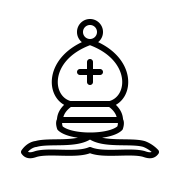

In [61]:
IMAGE_DATASET_ROWS = [
    {
        "image_id": "white-bishop-01",
        "caption": "a wtrclrchess white bishop, soft watercolor edges, plain background",
        "split": "train",
    },
    {
        "image_id": "black-knight-01",
        "caption": "a wtrclrchess black knight, soft watercolor edges, plain background",
        "split": "train",
    },
    {
        "image_id": "white-queen-01",
        "caption": "a wtrclrchess white queen, soft watercolor edges, plain background",
        "split": "train",
    },
    {
        "image_id": "black-king-01",
        "caption": "a wtrclrchess black king, soft watercolor edges, plain background",
        "split": "held out",
    },
]
show_table(IMAGE_DATASET_ROWS)
display(SVG(chess.svg.piece(chess.Piece(chess.BISHOP, chess.WHITE), size=180)))

The next figure is a worked visual stand-in, not output from a trained
adapter. It makes the desired before-and-after contract visible now. Replace
the right-hand panel with a pinned adapter output before using it as
evidence.

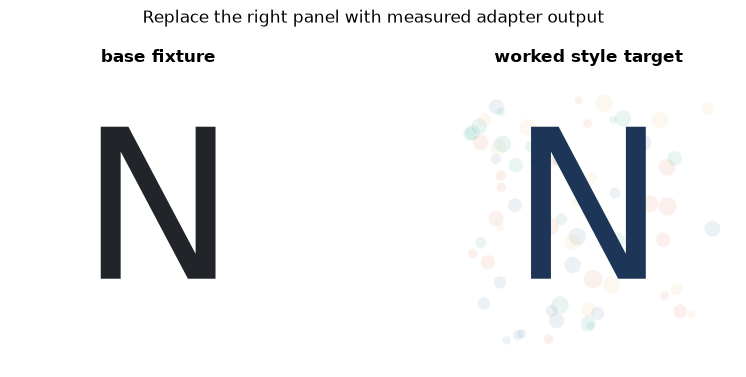

In [62]:
def draw_image_worked_example(seed: int = 11) -> None:
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
    for axis in axes:
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 1)
        axis.set_aspect("equal")
        axis.axis("off")

    axes[0].set_facecolor("#f1f3f5")
    axes[0].text(
        0.5, 0.48, "N", ha="center", va="center", fontsize=150, color="#212529"
    )
    axes[0].set_title("base fixture")

    palette = ("#2a9d8f", "#e9c46a", "#e76f51", "#457b9d")
    for _ in range(70):
        x, y = rng.uniform(0.08, 0.92, size=2)
        size = rng.uniform(25, 180)
        color = palette[int(rng.integers(0, len(palette)))]
        axes[1].scatter(x, y, s=size, color=color, alpha=0.10, edgecolors="none")
    axes[1].text(
        0.5, 0.48, "N", ha="center", va="center", fontsize=150, color="#1d3557"
    )
    axes[1].set_title("worked style target")
    fig.suptitle("Replace the right panel with measured adapter output")
    plt.tight_layout()
    plt.show()


draw_image_worked_example()

### Optional real Klein generation

The drawing above explains the target shape without spending money. This cell
calls the current distilled FLUX.2 Klein 4B endpoint on fal. It is provider
inference, not evidence that this repository trained an image adapter.

In [63]:
def generate_klein_piece(
    prompt: str = "a wtrclrchess white bishop, soft watercolor edges, plain background",
) -> dict[str, Any]:
    if not os.environ.get("FAL_KEY"):
        raise RuntimeError("Set FAL_KEY before running Klein")
    result = fal_client.subscribe(
        "fal-ai/flux-2/klein/4b",
        arguments={
            "prompt": prompt,
            "image_size": "square_hd",
            "num_images": 1,
            "output_format": "png",
        },
        with_logs=True,
    )
    images = result.get("images")
    if not isinstance(images, list) or not images or not isinstance(images[0], dict):
        raise RuntimeError(f"Klein returned no image: {str(result)[:300]}")
    image_url = images[0].get("url")
    if not isinstance(image_url, str) or not image_url:
        raise RuntimeError(f"Klein returned no image URL: {str(result)[:300]}")
    display(NotebookImage(url=image_url, width=512))
    return result


KLEIN_RESULT = generate_klein_piece()

In [23]:
IMAGE_EVALUATION_PLAN = [
    {
        "metric": "piece identity",
        "unit": "held-out prompts recognised as the requested piece",
        "method": "classifier or blinded human label",
    },
    {
        "metric": "style consistency",
        "unit": "set of outputs, not one image",
        "method": "embedding dispersion plus human review",
    },
    {
        "metric": "prompt adherence",
        "unit": "held-out caption and generated image",
        "method": "VLM rubric with audited samples",
    },
    {
        "metric": "caption sensitivity",
        "unit": "paired prompts with and without the identifier",
        "method": "compare controlled generations",
    },
]
show_table(IMAGE_EVALUATION_PLAN)

metric,unit,method
piece identity,held-out prompts recognised as the requested piece,classifier or blinded human label
style consistency,"set of outputs, not one image",embedding dispersion plus human review
prompt adherence,held-out caption and generated image,VLM rubric with audited samples
caption sensitivity,paired prompts with and without the identifier,compare controlled generations


A production comparison needs fixed seeds, held-out piece and color
combinations, saved base outputs, saved adapter outputs, and the same
evaluator for both. One VLM score on one image cannot measure consistency
or sensitivity.

In [24]:
show_table(
    [
        {
            "stage": "data",
            "image recipe": "piece images, captions, one preprocessing policy, held-out pieces",
        },
        {
            "stage": "baseline",
            "image recipe": "fixed prompts and seeds against the base checkpoint",
        },
        {
            "stage": "adaptation",
            "image recipe": "LoRA on the compatible trainable checkpoint",
        },
        {
            "stage": "evaluation",
            "image recipe": "identity, set-level style, adherence, pairwise preference",
        },
        {
            "stage": "evidence",
            "image recipe": "model IDs, revisions, seed, config, outputs, evaluator version",
        },
    ]
)

stage,image recipe
data,"piece images, captions, one preprocessing policy, held-out pieces"
baseline,fixed prompts and seeds against the base checkpoint
adaptation,LoRA on the compatible trainable checkpoint
evaluation,"identity, set-level style, adherence, pairwise preference"
evidence,"model IDs, revisions, seed, config, outputs, evaluator version"


## 4. Audio: adapting board sound

The pair is event text and an audio clip. The two clips below are generated
locally so this notebook remains playable offline. They are signal-processing
stand-ins, not MusicGen adapter outputs.

In [25]:
AUDIO_RATE = 16_000


def synthesize_capture(*, styled: bool, seed: int = 7) -> np.ndarray:
    duration = 0.40
    sample_count = int(AUDIO_RATE * duration)
    timeline = np.arange(sample_count) / AUDIO_RATE
    rng = np.random.default_rng(seed)
    envelope = np.exp(-timeline * (17 if styled else 28))
    base = 0.70 * np.sin(2 * np.pi * (620 if styled else 920) * timeline)
    harmonic = 0.22 * np.sin(2 * np.pi * (1240 if styled else 1840) * timeline)
    texture = 0.18 * rng.normal(size=sample_count) if styled else 0.0
    samples = envelope * (base + harmonic + texture)
    return np.clip(samples / max(np.max(np.abs(samples)), 1e-9) * 0.92, -1, 1)


def wav_bytes(samples: np.ndarray, sample_rate: int) -> bytes:
    buffer = io.BytesIO()
    pcm = np.round(np.clip(samples, -1, 1) * 32767).astype(np.int16)
    wavfile.write(buffer, sample_rate, pcm)
    return buffer.getvalue()


BASE_AUDIO = synthesize_capture(styled=False)
WORKED_AUDIO = synthesize_capture(styled=True)
display(Markdown("**Base fixture**"))
display(Audio(wav_bytes(BASE_AUDIO, AUDIO_RATE), rate=AUDIO_RATE))
display(Markdown("**Worked wood-texture target**"))
display(Audio(wav_bytes(WORKED_AUDIO, AUDIO_RATE), rate=AUDIO_RATE))

**Base fixture**

**Worked wood-texture target**

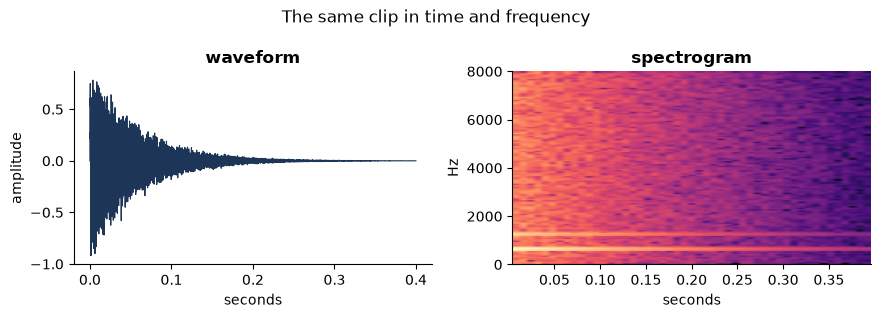

In [26]:
audio_time = np.arange(len(WORKED_AUDIO)) / AUDIO_RATE
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(audio_time, WORKED_AUDIO, color="#1d3557", linewidth=0.8)
axes[0].set_title("waveform")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("amplitude")
axes[1].specgram(WORKED_AUDIO, Fs=AUDIO_RATE, NFFT=256, noverlap=128, cmap="magma")
axes[1].set_title("spectrogram")
axes[1].set_xlabel("seconds")
axes[1].set_ylabel("Hz")
fig.suptitle("The same clip in time and frequency")
plt.tight_layout()
plt.show()

In [27]:
def audio_signal_metrics(samples: np.ndarray, sample_rate: int) -> dict[str, float]:
    duration = len(samples) / sample_rate
    clipping_rate = float(np.mean(np.abs(samples) >= 0.985))
    rms = float(np.sqrt(np.mean(np.square(samples))))
    spectrum = np.abs(np.fft.rfft(samples))
    frequencies = np.fft.rfftfreq(len(samples), d=1 / sample_rate)
    spectral_centroid = float(
        np.sum(frequencies * spectrum) / max(np.sum(spectrum), 1e-12)
    )
    return {
        "duration seconds": duration,
        "clipping rate": clipping_rate,
        "RMS": rms,
        "spectral centroid Hz": spectral_centroid,
    }


base_audio_metrics = audio_signal_metrics(BASE_AUDIO, AUDIO_RATE)
worked_audio_metrics = audio_signal_metrics(WORKED_AUDIO, AUDIO_RATE)
show_table(
    [
        {
            "artifact": "base fixture",
            **base_audio_metrics,
        },
        {
            "artifact": "worked target",
            **worked_audio_metrics,
        },
    ]
)

artifact,duration seconds,clipping rate,RMS,spectral centroid Hz
base fixture,0.400,0.000,0.127,1324.832
worked target,0.400,0.000,0.129,3003.683


Duration, clipping, level, and spectral centroid are computed from the
waveform. They do not establish prompt alignment. Use a shared audio-text
model such as CLAP for audio-text similarity. PANNs can supply audio tags or
audio embeddings; it does not directly embed the text prompt into the same
space. Event recognisability still needs labelled listeners or a validated
event classifier.

MusicGen Small is a 300M text-to-music model. A chess capture sound is a
short sound-effect task, so model choice and training data should reflect
that distinction.

In [28]:
show_table(
    [
        {
            "stage": "data",
            "audio recipe": (
                "event prompt, waveform, sample rate, duration, split by source recording"
            ),
        },
        {
            "stage": "baseline",
            "audio recipe": "generate held-out events with the base model",
        },
        {
            "stage": "adaptation",
            "audio recipe": "adapter supported by the selected audio model",
        },
        {
            "stage": "evaluation",
            "audio recipe": "duration, clipping, CLAP similarity, event recognition, preference",
        },
        {
            "stage": "evidence",
            "audio recipe": (
                "save WAV files, config, checkpoint revisions, prompts, and listener protocol"
            ),
        },
    ]
)

stage,audio recipe
data,"event prompt, waveform, sample rate, duration, split by source recording"
baseline,generate held-out events with the base model
adaptation,adapter supported by the selected audio model
evaluation,"duration, clipping, CLAP similarity, event recognition, preference"
evidence,"save WAV files, config, checkpoint revisions, prompts, and listener protocol"


## 5. Video: staging the real-world case

The video model does not reenact a chess move. Luna reads the game, explains
a real-world situation with the same tension, and writes the detailed scene
prompt. LTX, Veo, or another video model receives only that scene prompt.

LTX recommends one flowing paragraph with a shot, setting, observable
action, character detail, camera movement, lighting, and sound. Four to
eight sentences is enough detail without asking one short clip to stage five
different scenes.

In [29]:
VIDEO_SCENARIO_FIXTURE = {
    "source_game": "fools-mate",
    "assessment": (
        "White weakens the same diagonal twice, and Black ends the game before White can recover."
    ),
    "real_world": (
        "A small release team disables two routine safeguards to ship before a deadline. "
        "The shortcuts expose one direct path from an ordinary mistake to a production incident. "
        "A routine deployment then fails before the team has prepared a rollback. The parallel is "
        "not that one person is careless; it is that two small concessions remove every useful "
        "response to the next problem."
    ),
    "video_prompt": (
        "A medium-wide documentary shot opens inside a small software operations room late in the "
        "afternoon. A release manager in a grey overshirt stands between two plain consoles as one "
        "amber warning light activates on each side of the room. She enters a final command on an "
        "unlabelled keyboard, the cooling fans rise, and both lights turn red while a colleague "
        "wheels across the floor to disconnect a cable cabinet. The camera makes a slow dolly from "
        "the doorway to her side profile, keeping her and both consoles in frame as the failed "
        "response unfolds. Cool fluorescent ceiling light mixes with muted monitor light on the "
        "desks; there are no readable interfaces or logos. The audio is restrained: ventilation, "
        "keyboard taps, chair wheels, two warning tones, and a final relay click."
    ),
    "provenance": "offline contract fixture; replace with a saved Luna response",
}
show_table(
    [
        {
            "source game": VIDEO_SCENARIO_FIXTURE["source_game"],
            "assessment": VIDEO_SCENARIO_FIXTURE["assessment"],
            "real-world case": VIDEO_SCENARIO_FIXTURE["real_world"],
        }
    ]
)
show_markdown(
    "LTX-ready prompt:\n\n" + indented(VIDEO_SCENARIO_FIXTURE["video_prompt"])
)

source game,assessment,real-world case
fools-mate,"White weakens the same diagonal twice, and Black ends the game before White can recover.",A small release team disables two routine safeguards to ship before a deadline. The shortcuts expose one direct path from an ordinary mistake to a production incident. A routine deployment then fails before the team has prepared a rollback. The parallel is not that one person is careless; it is that two small concessions remove every useful response to the next problem.


LTX-ready prompt:

    A medium-wide documentary shot opens inside a small software operations room late in the afternoon. A release manager in a grey overshirt stands between two plain consoles as one amber warning light activates on each side of the room. She enters a final command on an unlabelled keyboard, the cooling fans rise, and both lights turn red while a colleague wheels across the floor to disconnect a cable cabinet. The camera makes a slow dolly from the doorway to her side profile, keeping her and both consoles in frame as the failed response unfolds. Cool fluorescent ceiling light mixes with muted monitor light on the desks; there are no readable interfaces or logos. The audio is restrained: ventilation, keyboard taps, chair wheels, two warning tones, and a final relay click.

### Optional real LTX generation

The scenario writer and the video generator use different credentials.
OpenAI or OpenRouter writes `video_prompt`; fal receives only that prompt and
uses `FAL_KEY`. The result depicts the real-world case, not a chess move.

In [ ]:
def generate_ltx_video(scenario: dict[str, str]) -> dict[str, Any]:
    if not os.environ.get("FAL_KEY"):
        raise RuntimeError("Set FAL_KEY before running LTX")
    prompt = scenario.get("video_prompt", "").strip()
    if not prompt:
        raise ValueError("The scenario needs a non-empty video_prompt")
    result = fal_client.subscribe(
        "fal-ai/ltx-2.3/text-to-video/fast",
        arguments={
            "prompt": prompt,
            "duration": 6,
            "resolution": "1080p",
            "aspect_ratio": "16:9",
            "fps": 25,
            "generate_audio": True,
        },
        with_logs=True,
    )
    video = result.get("video")
    if not isinstance(video, dict) or not isinstance(video.get("url"), str):
        raise RuntimeError(f"LTX returned no video URL: {str(result)[:300]}")
    display(Video(url=video["url"], width=800, html_attributes="controls playsinline"))
    return result


# Use the offline prompt without a hosted text call:
# LTX_RESULT = generate_ltx_video(VIDEO_SCENARIO_FIXTURE)

# Or generate the scenario through the selected hosted provider first:
# LIVE_VIDEO_SCENARIO = draft_video_scenario(REPLAYED_GAMES["fools-mate"])
# LTX_RESULT = generate_ltx_video(LIVE_VIDEO_SCENARIO)

The fixture above proves the prompt contract offline; it is not attributed to
Luna. The optional cell above sends that real-world prompt to LTX and returns
an actual video. The GIFs below are deliberately simple drawings used to
isolate one evaluation failure: the same person changes appearance between
frames. They are not video-model outputs.

**Base fixture: the lead's appearance flickers**

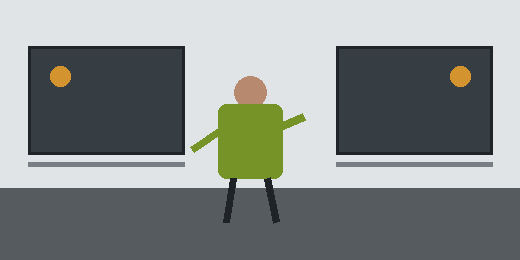

**Worked target: the lead remains visually consistent**

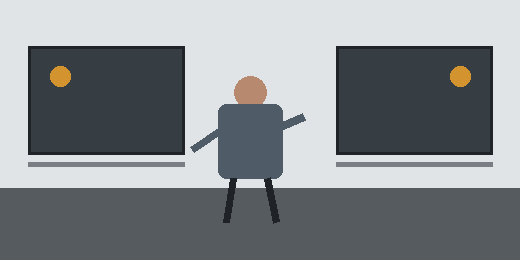

In [30]:
def make_video_fixture(
    *,
    flicker: bool,
    seed: int = 17,
) -> tuple[bytes, np.ndarray]:
    rng = np.random.default_rng(seed)
    frames: list[PILImage.Image] = []
    subject_colors: list[tuple[int, int, int]] = []
    for frame_index in range(12):
        frame = PILImage.new("RGB", (520, 260), (224, 228, 231))
        draw = ImageDraw.Draw(frame)
        draw.rectangle((0, 188, 520, 260), fill=(86, 91, 96))
        draw.rectangle(
            (28, 46, 184, 154), fill=(54, 61, 67), outline=(32, 36, 40), width=3
        )
        draw.rectangle(
            (336, 46, 492, 154), fill=(54, 61, 67), outline=(32, 36, 40), width=3
        )
        warning_color = (194, 58, 43) if frame_index >= 5 else (211, 148, 47)
        draw.ellipse((50, 66, 70, 86), fill=warning_color)
        draw.ellipse((450, 66, 470, 86), fill=warning_color)
        draw.line((28, 164, 184, 164), fill=(120, 126, 131), width=5)
        draw.line((336, 164, 492, 164), fill=(120, 126, 131), width=5)

        x_position = 218 + frame_index * 7
        color_jitter = (
            rng.integers(-80, 81, size=3) if flicker else np.zeros(3, dtype=int)
        )
        base_color = np.array((79, 91, 102))
        subject_color = tuple(np.clip(base_color + color_jitter, 20, 220).astype(int))
        subject_colors.append(subject_color)
        draw.ellipse((x_position + 16, 76, x_position + 48, 108), fill=(183, 137, 111))
        draw.rounded_rectangle(
            (x_position, 104, x_position + 64, 178),
            radius=8,
            fill=subject_color,
        )
        draw.line(
            (x_position + 15, 178, x_position + 8, 222), fill=(31, 35, 39), width=7
        )
        draw.line(
            (x_position + 49, 178, x_position + 58, 222), fill=(31, 35, 39), width=7
        )
        draw.line(
            (x_position + 6, 128, x_position - 26, 150), fill=subject_color, width=8
        )
        draw.line(
            (x_position + 58, 128, x_position + 86, 116), fill=subject_color, width=8
        )
        frames.append(frame)

    buffer = io.BytesIO()
    frames[0].save(
        buffer,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=110,
        loop=0,
    )
    return buffer.getvalue(), np.asarray(subject_colors, dtype=float)


BASE_VIDEO_GIF, BASE_VIDEO_COLORS = make_video_fixture(flicker=True)
WORKED_VIDEO_GIF, WORKED_VIDEO_COLORS = make_video_fixture(flicker=False)
display(Markdown("**Base fixture: the lead's appearance flickers**"))
display(NotebookImage(data=BASE_VIDEO_GIF, format="gif"))
display(Markdown("**Worked target: the lead remains visually consistent**"))
display(NotebookImage(data=WORKED_VIDEO_GIF, format="gif"))

In [31]:
def subject_color_consistency(colors: np.ndarray) -> float:
    channel_variation = np.mean(np.std(colors, axis=0))
    return float(np.clip(1 - channel_variation / 128, 0, 1))


show_table(
    [
        {
            "artifact": "base fixture",
            "subject-color consistency": subject_color_consistency(BASE_VIDEO_COLORS),
            "frames": len(BASE_VIDEO_COLORS),
        },
        {
            "artifact": "worked target",
            "subject-color consistency": subject_color_consistency(WORKED_VIDEO_COLORS),
            "frames": len(WORKED_VIDEO_COLORS),
        },
    ]
)

artifact,subject-color consistency,frames
base fixture,0.666,12
worked target,1.000,12


Raw frame-to-frame pixel difference would also increase when the object
moves correctly. Production temporal evaluation should account for motion,
then inspect subject identity, scene structure, and action consistency. A
separate rubric checks that the clip stages Luna's real-world case rather
than merely matching a few nouns from the prompt.

In [32]:
show_table(
    [
        {
            "stage": "data",
            "video recipe": "game, saved Luna mapping, scene prompt, clip, provenance",
        },
        {
            "stage": "baseline",
            "video recipe": "fixed held-out Luna prompts with saved base outputs",
        },
        {
            "stage": "adaptation",
            "video recipe": "LoRA on one compatible video checkpoint",
        },
        {
            "stage": "evaluation",
            "video recipe": "case fidelity, action, subject continuity, coherence, preference",
        },
        {
            "stage": "evidence",
            "video recipe": "save clips, model revision, seed, prompt, duration, and cost",
        },
    ]
)

stage,video recipe
data,"game, saved Luna mapping, scene prompt, clip, provenance"
baseline,fixed held-out Luna prompts with saved base outputs
adaptation,LoRA on one compatible video checkpoint
evaluation,"case fidelity, action, subject continuity, coherence, preference"
evidence,"save clips, model revision, seed, prompt, duration, and cost"


Synthetic clips produced by a stronger model can become training data, but
that is not automatically distillation. Record the generator, prompts,
filtering, and licence, and keep synthetic families on one side of the
evaluation split.

## 6. What transfers, and what does not

In [33]:
TRANSFER_TABLE = [
    {
        "question": "What is one pair?",
        "text": "position and move",
        "image": "image and caption",
        "audio": "prompt and waveform",
        "video": "Luna scene prompt and clip",
    },
    {
        "question": "What must be held out?",
        "text": "whole games",
        "image": "subjects and prompt combinations",
        "audio": "source recordings and events",
        "video": "games, scenarios, and synthetic source families",
    },
    {
        "question": "Cheap automatic check",
        "text": "JSON and legality",
        "image": "dimensions and identity classifier",
        "audio": "duration and clipping",
        "video": "decode, duration, motion-aware features",
    },
    {
        "question": "Expensive check",
        "text": "engine and human teaching quality",
        "image": "set-level style and preference",
        "audio": "recognisability and preference",
        "video": "case fidelity, action, subject continuity, coherence",
    },
    {
        "question": "Typical mistake",
        "text": "evaluating training rows",
        "image": "caption-only dataset thinking",
        "audio": "using signal quality as prompt alignment",
        "video": "using pixel difference as coherence",
    },
]
show_table(TRANSFER_TABLE)

question,text,image,audio,video
What is one pair?,position and move,image and caption,prompt and waveform,Luna scene prompt and clip
What must be held out?,whole games,subjects and prompt combinations,source recordings and events,"games, scenarios, and synthetic source families"
Cheap automatic check,JSON and legality,dimensions and identity classifier,duration and clipping,"decode, duration, motion-aware features"
Expensive check,engine and human teaching quality,set-level style and preference,recognisability and preference,"case fidelity, action, subject continuity, coherence"
Typical mistake,evaluating training rows,caption-only dataset thinking,using signal quality as prompt alignment,using pixel difference as coherence


The stable part is experimental discipline, not a slogan: define the pair,
preserve provenance, hold out the right unit, compare the same cases, and
retain the raw outputs.

## 7. Merging compatible text checkpoints

Weight merging is not cross-modality composition. It does not combine the
text adapter, image adapter, audio adapter, and video adapter. Those models
have different architectures.

The configuration below is a shape for two complete compatible text
checkpoints. Raw PEFT adapter directories must first be applied to their
common base, or combined with an adapter-aware method. SLERP requires a
designated base model.

In [34]:
MERGEKIT_CONFIG = """merge_method: slerp
base_model: outputs/chess-player-full
models:
  - model: outputs/chess-player-full
  - model: outputs/chess-analyst-full
parameters:
  t: 0.5
dtype: bfloat16
tokenizer:
  source: base
"""
print(MERGEKIT_CONFIG)

merge_method: slerp
base_model: outputs/chess-player-full
models:
  - model: outputs/chess-player-full
  - model: outputs/chess-analyst-full
parameters:
  t: 0.5
dtype: bfloat16
tokenizer:
  source: base



Evaluate the player task, analyst task, and general regressions before and
after merging. A successful command only proves that tensors were combined.

## Closing

The useful question is not whether one recipe works everywhere. It does not.
The useful question is which decisions repeat: task definition, data
provenance, compatible adaptation, and held-out evaluation.

My target remains concrete: an instructor that teaches me to win while
capturing as few opposing pieces as possible. The text model can choose and
explain a move. The image model can give the board a consistent visual
language. The audio model can make events recognisable without looking. The
video model can stage the real-world case Luna derives from a game. Each
requires its own evidence.

The notebook is complete when the worked media stand-ins are replaced by
measured, reproducible adapter outputs. Until then, they are useful teaching
aids and nothing more.

---

# Reference A: FEN anatomy

FEN has six fields: piece placement, side to move, castling rights, en
passant target, halfmove clock, and fullmove number. It captures the current
rule state but not full repetition history.

In [35]:
STARTING_FEN_FIELDS = chess.STARTING_FEN.split()
show_table(
    [
        {"field": "piece placement", "value": STARTING_FEN_FIELDS[0]},
        {"field": "side to move", "value": STARTING_FEN_FIELDS[1]},
        {"field": "castling rights", "value": STARTING_FEN_FIELDS[2]},
        {"field": "en passant", "value": STARTING_FEN_FIELDS[3]},
        {"field": "halfmove clock", "value": STARTING_FEN_FIELDS[4]},
        {"field": "fullmove number", "value": STARTING_FEN_FIELDS[5]},
    ]
)

field,value
piece placement,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR
side to move,w
castling rights,KQkq
en passant,-
halfmove clock,0
fullmove number,1


PGN can also specify a custom starting FEN in its headers. SAN moves are
contextual and require the board at that point. UCI targets are easier to
validate, but they are not easier for a person to read.

# Reference B: training ladder

These are reference configurations, not cells to run during the workshop.
Pin exact package and model revisions on the rehearsal machine. Materialise
the dataset before allocating a GPU.

Gemma's QAT GGUF is the local deployment checkpoint. It is ready for
llama.cpp-style inference, but GGUF is not the input expected by the TRL and
Axolotl adapter examples below. Those use the matching unquantized QAT
checkpoint. After tuning, merge the adapter, convert the result to GGUF, and
rerun the same held-out cases against the deployed file.

In [36]:
GEMMA_LOCAL_COMMAND = f"llama serve -hf {GEMMA_LOCAL_MODEL_ID}:Q4_0"
show_table(
    [
        {
            "role": "local baseline and deployment",
            "checkpoint": GEMMA_LOCAL_MODEL_ID,
            "format": "QAT Q4_0 GGUF",
        },
        {
            "role": "adapter training source",
            "checkpoint": GEMMA_TRAINING_MODEL_ID,
            "format": "unquantized QAT weights",
        },
    ]
)
print(GEMMA_LOCAL_COMMAND)

role,checkpoint,format
local baseline and deployment,google/gemma-4-E2B-it-qat-q4_0-gguf,QAT Q4_0 GGUF
adapter training source,google/gemma-4-E2B-it-qat-q4_0-unquantized,unquantized QAT weights


llama serve -hf google/gemma-4-E2B-it-qat-q4_0-gguf:Q4_0


In [37]:
TRAINING_LADDER = [
    {
        "level": "UI",
        "example": "Unsloth Studio",
        "inspect before training": "rendered rows, split, model, adapter settings",
    },
    {
        "level": "managed API",
        "example": "provider training endpoint",
        "inspect before training": "uploaded file, base model, pricing, retention",
    },
    {
        "level": "configuration",
        "example": "Axolotl",
        "inspect before training": "preprocessed prompt and masked labels",
    },
    {
        "level": "Python",
        "example": "TRL plus PEFT",
        "inspect before training": "tokenizer output, completion mask, held-out callback",
    },
    {
        "level": "calculation",
        "example": "JAX directly",
        "inspect before training": "frozen weights, trainable adapter, loss, gradients",
    },
]
show_table(TRAINING_LADDER)

level,example,inspect before training
UI,Unsloth Studio,"rendered rows, split, model, adapter settings"
managed API,provider training endpoint,"uploaded file, base model, pricing, retention"
configuration,Axolotl,preprocessed prompt and masked labels
Python,TRL plus PEFT,"tokenizer output, completion mask, held-out callback"
calculation,JAX directly,"frozen weights, trainable adapter, loss, gradients"


### Direct JAX: what a low-rank adapter changes

The cell below isolates the calculation behind a low-rank adapter. The
frozen matrix stands in for one projection in a pretrained model. JAX only
differentiates the two adapter matrices, so the base cannot change by
accident. The chess positions and targets are real; the small projection is
a teaching model, not evidence of useful chess behaviour.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


calculation,initial loss,final loss,frozen parameters,trained parameters,trained share
direct JAX adapter,2.947,2.242,21888,4684,0.214


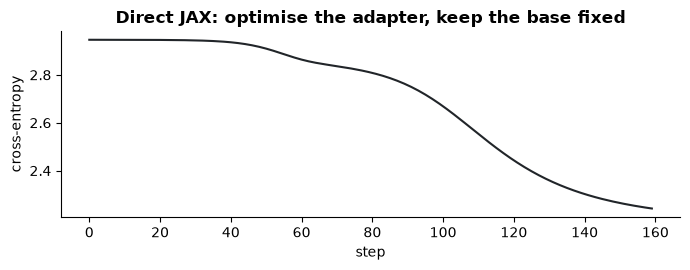

In [38]:
jax_feature_rows = np.stack(
    [board_planes(record.fen_before).reshape(-1) for record in TRAIN_RECORDS]
)
jax_feature_rows /= np.linalg.norm(jax_feature_rows, axis=1, keepdims=True)
JAX_FEATURES = jnp.asarray(jax_feature_rows)
JAX_MOVE_VOCAB = tuple(sorted({record.uci for record in TRAIN_RECORDS}))
JAX_MOVE_INDEX = {move: index for index, move in enumerate(JAX_MOVE_VOCAB)}
JAX_LABELS = jnp.asarray([JAX_MOVE_INDEX[record.uci] for record in TRAIN_RECORDS])

JAX_ADAPTER_RANK = 4
JAX_ADAPTER_ALPHA = 4.0
base_key, adapter_key = jax.random.split(jax.random.key(17))
FROZEN_BASE = 0.02 * jax.random.normal(
    base_key,
    (JAX_FEATURES.shape[1], len(JAX_MOVE_VOCAB)),
)
jax_adapter = {
    "a": 0.02
    * jax.random.normal(
        adapter_key,
        (JAX_FEATURES.shape[1], JAX_ADAPTER_RANK),
    ),
    "b": jnp.zeros((JAX_ADAPTER_RANK, len(JAX_MOVE_VOCAB))),
}


def jax_adapter_logits(params: dict[str, jax.Array], features: jax.Array) -> jax.Array:
    scale = JAX_ADAPTER_ALPHA / JAX_ADAPTER_RANK
    low_rank_delta = scale * (params["a"] @ params["b"])
    return features @ (FROZEN_BASE + low_rank_delta)


def jax_adapter_loss(
    params: dict[str, jax.Array],
    features: jax.Array,
    labels: jax.Array,
) -> jax.Array:
    log_probabilities = jax.nn.log_softmax(jax_adapter_logits(params, features))
    return -jnp.mean(log_probabilities[jnp.arange(labels.shape[0]), labels])


@jax.jit
def jax_adapter_step(
    params: dict[str, jax.Array],
    features: jax.Array,
    labels: jax.Array,
    learning_rate: float,
) -> tuple[dict[str, jax.Array], jax.Array]:
    loss, gradients = jax.value_and_grad(jax_adapter_loss)(params, features, labels)
    updated = jax.tree.map(
        lambda parameter, gradient: parameter - learning_rate * gradient,
        params,
        gradients,
    )
    return updated, loss


jax_losses: list[float] = []
for _ in range(160):
    jax_adapter, loss = jax_adapter_step(
        jax_adapter,
        JAX_FEATURES,
        JAX_LABELS,
        0.8,
    )
    jax_losses.append(float(loss))

full_projection_parameters = int(FROZEN_BASE.size)
adapter_parameters = sum(
    int(parameter.size) for parameter in jax.tree.leaves(jax_adapter)
)
show_table(
    [
        {
            "calculation": "direct JAX adapter",
            "initial loss": jax_losses[0],
            "final loss": jax_losses[-1],
            "frozen parameters": full_projection_parameters,
            "trained parameters": adapter_parameters,
            "trained share": adapter_parameters / full_projection_parameters,
        }
    ]
)

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(jax_losses, color="#212529")
ax.set_xlabel("step")
ax.set_ylabel("cross-entropy")
ax.set_title("Direct JAX: optimise the adapter, keep the base fixed")
plt.tight_layout()
plt.show()

In [39]:
TRL_PEFT_REFERENCE = f"""from datasets import load_dataset
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer

dataset = load_dataset(
    "json",
    data_files="{TRAINING_PATH}",
    split="train",
)

trainer = SFTTrainer(
    model="{GEMMA_TRAINING_MODEL_ID}",
    train_dataset=dataset,
    peft_config=LoraConfig(r=16, lora_alpha=32),
    args=SFTConfig(
        completion_only_loss=True,
        max_length=2048,
        learning_rate=2e-4,
        num_train_epochs=1,
        output_dir="outputs/chess-lora",
    ),
)
trainer.train()
"""
print(TRL_PEFT_REFERENCE)

from datasets import load_dataset
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer

dataset = load_dataset(
    "json",
    data_files="/tmp/ftshop-chess-sft.jsonl",
    split="train",
)

trainer = SFTTrainer(
    model="google/gemma-4-E2B-it-qat-q4_0-unquantized",
    train_dataset=dataset,
    peft_config=LoraConfig(r=16, lora_alpha=32),
    args=SFTConfig(
        completion_only_loss=True,
        max_length=2048,
        learning_rate=2e-4,
        num_train_epochs=1,
        output_dir="outputs/chess-lora",
    ),
)
trainer.train()



In [40]:
AXOLOTL_REFERENCE = f"""base_model: {GEMMA_TRAINING_MODEL_ID}
load_in_4bit: true
adapter: lora
lora_r: 16
lora_alpha: 32

datasets:
  - path: {TRAINING_PATH}
    type:
      field_instruction: prompt
      field_output: completion
      format: "{{instruction}}"
      no_input_format: "{{instruction}}"

train_on_inputs: false
sequence_len: 2048
micro_batch_size: 1
gradient_accumulation_steps: 4
num_epochs: 1
learning_rate: 0.0002
output_dir: outputs/chess-lora
"""
print(AXOLOTL_REFERENCE)

base_model: google/gemma-4-E2B-it-qat-q4_0-unquantized
load_in_4bit: true
adapter: lora
lora_r: 16
lora_alpha: 32

datasets:
  - path: /tmp/ftshop-chess-sft.jsonl
    type:
      field_instruction: prompt
      field_output: completion
      format: "{instruction}"
      no_input_format: "{instruction}"

train_on_inputs: false
sequence_len: 2048
micro_batch_size: 1
gradient_accumulation_steps: 4
num_epochs: 1
learning_rate: 0.0002
output_dir: outputs/chess-lora



Run axolotl preprocess CONFIG --debug before training. Confirm that the
completion is present, prompt tokens are masked as intended, and inference
uses the same formatting. Hardware claims belong in the rehearsal record,
not in this notebook until measured.

# Resources

- python-chess: https://python-chess.readthedocs.io/
- Gemma 4 QAT GGUF: https://huggingface.co/google/gemma-4-E2B-it-qat-q4_0-gguf
- Gemma 4 QAT formats: https://ai.google.dev/gemma/docs/core#quantization
- JAX automatic differentiation: https://docs.jax.dev/en/latest/automatic-differentiation.html
- TRL SFTTrainer: https://huggingface.co/docs/trl/sft_trainer
- Axolotl dataset formats: https://docs.axolotl.ai/docs/dataset-formats/
- PEFT LoRA: https://huggingface.co/docs/peft/
- Diffusers training: https://huggingface.co/docs/diffusers/training/overview
- MusicGen model card: https://huggingface.co/facebook/musicgen-small
- LTX prompting guide: https://docs.ltx.video/open-source-model/usage-guides/prompting-guide
- mergekit: https://github.com/arcee-ai/mergekit
- workshop repository: the parent directory of this notebook